# EDA 01 — GB Stations Reference

**Data source**: `rail-road-data` container — `gb_stations.csv`  
**Loaded by**: `src/data_loader.load_stations()`  
**Output**: `data/processed/stations_reference.parquet`

This notebook explores the GB stations reference dataset, which serves two purposes in the pipeline: (1) providing station coordinates for the haversine spatial join, and (2) providing station names and three-letter codes (TLC) for human-readable output. Understanding coverage, geographic spread, and ownership distribution ensures the reference data is fit for these purposes.

---
**Sections**
1. Load and inspect  
2. Missing value audit  
3. Owner/operator distribution  
4. Geographic distribution  
5. Footfall analysis (2017–2025)  
6. TIPLOC lookup coverage check  
7. Save output  


## 0. Setup

In [3]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_03", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load and Inspect

In [4]:
from src.data_loader import load_stations, load_stations_lookup

stations_df = load_stations()
print(f"Shape: {stations_df.shape}")
print(f"Columns: {list(stations_df.columns)}")

data\rail\gb_stations.csv
Shape: (2595, 49)
Columns: ['Station', 'Postcode', 'Latitude', 'Longitude', 'TLC', 'NLC', 'Owner', 'Entries and exits 2025', ' Entries and exits 2024', ' Entries and exits 2023', ' Entries and exits 2022', ' Entries and exits 2021', ' Entries and exits 2020', ' Entries and exits 2019', ' Entries and exits 2018', ' Entries and exits 2017', ' Entries and exits 2016', ' Entries and exits 2015', ' Entries and exits 2014', ' Entries and exits 2013', ' Entries and exits 2012', ' Entries and exits 2011', ' Entries and exits 2010', ' Entries and exits 2009', ' Entries and exits 2008', ' Entries and exits 2007', ' Entries and exits 2006', ' Entries and exits 2005', ' Interchanges 2025', 'Interchanges 2024', 'Interchanges 2023', 'Interchanges 2022', 'Interchanges 2021', 'Interchanges 2020', 'Interchanges 2019', 'Interchanges 2018', 'Interchanges 2017', 'Interchanges 2016', 'Interchanges 2015', 'Interchanges 2014', 'Interchanges 2013', 'Interchanges 2012', 'Interchanges 

In [5]:
stations_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2595 entries, 0 to 2594
Data columns (total 49 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Station                  2595 non-null   str    
 1   Postcode                 2595 non-null   str    
 2   Latitude                 2595 non-null   float64
 3   Longitude                2595 non-null   float64
 4   TLC                      2595 non-null   str    
 5   NLC                      2594 non-null   float64
 6   Owner                    2595 non-null   str    
 7   Entries and exits 2025   2588 non-null   float64
 8    Entries and exits 2024  2584 non-null   float64
 9    Entries and exits 2023  2577 non-null   float64
 10   Entries and exits 2022  2569 non-null   float64
 11   Entries and exits 2021  2569 non-null   float64
 12   Entries and exits 2020  2569 non-null   float64
 13   Entries and exits 2019  2565 non-null   float64
 14   Entries and exits 2018  2559 non-n

In [6]:
stations_df.head()

,Station,Postcode,Latitude,Longitude,TLC,NLC,Owner,Entries and exits 2025,Entries and exits 2024,Entries and exits 2023,Entries and exits 2022,Entries and exits 2021,Entries and exits 2020,Entries and exits 2019,Entries and exits 2018,Entries and exits 2017,Entries and exits 2016,Entries and exits 2015,Entries and exits 2014,Entries and exits 2013,...,Interchanges 2024,Interchanges 2023,Interchanges 2022,Interchanges 2021,Interchanges 2020,Interchanges 2019,Interchanges 2018,Interchanges 2017,Interchanges 2016,Interchanges 2015,Interchanges 2014,Interchanges 2013,Interchanges 2012,Interchanges 2011,Interchanges 2010,Interchanges 2009,Interchanges 2008,Interchanges 2007,Interchanges 2006,Interchanges 2005
0,Abbey Wood,SE2 9RH,51.491061,0.121394,ABW,5131.0,TfL Rail,11873686.0,10655006.0,7118664.0,2638456.0,1412638.0,3825206.0,3769402.0,3124856.0,2988802.0,2929472.0,3319408.0,3282240.0,3175430.0,...,1888592.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Aber,CF83 1AQ,51.574969,-3.229829,ABE,3813.0,TfW Rail,145234.0,136896.0,103976.0,73642.0,15712.0,228480.0,245218.0,251108.0,227270.0,214996.0,212546.0,219868.0,209622.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Abercynon,CF45 4SE,51.644712,-3.326989,ACY,3801.0,TfW Rail,189820.0,144514.0,134880.0,105822.0,33006.0,282886.0,289008.0,298358.0,293638.0,275404.0,265458.0,251688.0,243948.0,...,15129.0,15581.0,11592.0,1887.0,29079.0,33607.0,36440.0,42087.0,41720.0,40847.0,42347.0,35871.0,35304.0,33225.0,29324.0,28775.0,NaN,NaN,NaN,NaN
3,Aberdare,CF44 0PU,51.715062,-3.443084,ABA,3982.0,TfW Rail,341438.0,238580.0,226714.0,177350.0,53668.0,504622.0,555780.0,571746.0,569364.0,566904.0,551928.0,557992.0,552436.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aberdeen,AB11 6LX,57.143706,-2.098685,ABD,8976.0,ScotRail,2377660.0,2287858.0,1961414.0,1536720.0,393982.0,2497108.0,2616142.0,2948186.0,3058268.0,3459944.0,3742646.0,3599431.0,3338072.0,...,202181.0,179272.0,124666.0,27863.0,237220.0,258416.0,179958.0,192344.0,204139.0,219002.0,219085.0,200864.0,197046.0,148594.0,164299.0,162526.0,119259.0,230788.0,201417.0,187983.0


In [7]:
stations_df.describe()

,Latitude,Longitude,NLC,Entries and exits 2025,Entries and exits 2024,Entries and exits 2023,Entries and exits 2022,Entries and exits 2021,Entries and exits 2020,Entries and exits 2019,Entries and exits 2018,Entries and exits 2017,Entries and exits 2016,Entries and exits 2015,Entries and exits 2014,Entries and exits 2013,Entries and exits 2012,Entries and exits 2011,Entries and exits 2010,Entries and exits 2009,...,Interchanges 2024,Interchanges 2023,Interchanges 2022,Interchanges 2021,Interchanges 2020,Interchanges 2019,Interchanges 2018,Interchanges 2017,Interchanges 2016,Interchanges 2015,Interchanges 2014,Interchanges 2013,Interchanges 2012,Interchanges 2011,Interchanges 2010,Interchanges 2009,Interchanges 2008,Interchanges 2007,Interchanges 2006,Interchanges 2005
count,2595.000000,2595.000000,2594.000000,2.588000e+03,2.584000e+03,2.577000e+03,2.569000e+03,2.569000e+03,2.569000e+03,2.565000e+03,2.559000e+03,2.556000e+03,2.553000e+03,2.541000e+03,2.536000e+03,2.534000e+03,2.538000e+03,2.530000e+03,2.515000e+03,2.507000e+03,...,2.584000e+03,2.577000e+03,2.569000e+03,2.569000e+03,2.569000e+03,2.565000e+03,2.559000e+03,2.556000e+03,2.553000e+03,2.541000e+03,2.536000e+03,2.534000e+03,2.538000e+03,2.530000e+03,2.515000e+03,2.507000e+03,2.502000e+03,2.496000e+03,2.478000e+03,2.473000e+03
mean,52.807835,-1.771153,5302.369314,1.180377e+06,1.100804e+06,9.513528e+05,6.961768e+05,2.677045e+05,1.170550e+06,1.184965e+06,1.152706e+06,1.149978e+06,1.146703e+06,1.096034e+06,1.050888e+06,1.001514e+06,9.727048e+05,9.144888e+05,8.468835e+05,8.490848e+05,...,8.490699e+04,8.281475e+04,5.510644e+04,2.153246e+04,9.599958e+04,9.710992e+04,9.363513e+04,8.735833e+04,8.701776e+04,9.068872e+04,8.919233e+04,8.332317e+04,7.964183e+04,6.542682e+04,6.096572e+04,5.725995e+04,5.700712e+04,5.307909e+04,4.812598e+04,4.845604e+04
std,1.746437,1.691841,2548.482004,4.598663e+06,4.340755e+06,3.634607e+06,2.286673e+06,8.468101e+05,4.244338e+06,4.338410e+06,4.204296e+06,4.248462e+06,4.252719e+06,4.138550e+06,4.037159e+06,3.851840e+06,3.767019e+06,3.612348e+06,3.399814e+06,3.430436e+06,...,6.509696e+05,6.176866e+05,3.952654e+05,1.732887e+05,7.119001e+05,7.429325e+05,7.377431e+05,6.728471e+05,7.189385e+05,7.369730e+05,7.096155e+05,6.398701e+05,6.149465e+05,5.305238e+05,5.223799e+05,4.394617e+05,4.624316e+05,3.862095e+05,3.264001e+05,3.493616e+05
min,50.121681,-5.839079,244.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.000000e+00,8.000000e+00,0.000000e+00,1.800000e+01,4.200000e+01,4.400000e+01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,51.463398,-3.073452,3052.250000,6.563600e+04,5.847450e+04,5.240200e+04,4.148000e+04,1.322000e+04,6.455000e+04,6.102000e+04,6.141400e+04,6.028800e+04,5.868400e+04,5.715200e+04,5.534350e+04,5.217000e+04,5.088750e+04,4.826150e+04,4.574500e+04,4.344600e+04,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,52.345076,-1.706375,5317.500000,2.313340e+05,2.108100e+05,1.856900e+05,1.514320e+05,5.159400e+04,2.459780e+05,2.467700e+05,2.473520e+05,2.440250e+05,2.401120e+05,2.371980e+05,2.303850e+05,2.236430e+05,2.159150e+05,2.055070e+05,1.915000e+05,1.892800e+05,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,53.650521,-0.237319,7213.500000,8.038440e+05,7.411595e+05,6.332920e+05,5.188060e+05,2.0

## 2. Missing Value Audit

In [8]:
missing = pd.DataFrame({
    "missing_count": stations_df.isna().sum(),
    "missing_pct": (stations_df.isna().sum() / len(stations_df) * 100).round(2)
}).sort_values("missing_pct", ascending=False)
print(missing.to_string())

                         missing_count  missing_pct
 Entries and exits 2005            122         4.70
Interchanges 2005                  122         4.70
Interchanges 2006                  117         4.51
 Entries and exits 2006            117         4.51
 Entries and exits 2007             99         3.82
Interchanges 2007                   99         3.82
Interchanges 2008                   93         3.58
 Entries and exits 2008             93         3.58
 Entries and exits 2009             88         3.39
Interchanges 2009                   88         3.39
Interchanges 2010                   80         3.08
 Entries and exits 2010             80         3.08
 Entries and exits 2011             65         2.50
Interchanges 2011                   65         2.50
Interchanges 2013                   61         2.35
 Entries and exits 2013             61         2.35
Interchanges 2014                   59         2.27
 Entries and exits 2014             59         2.27
 Entries and

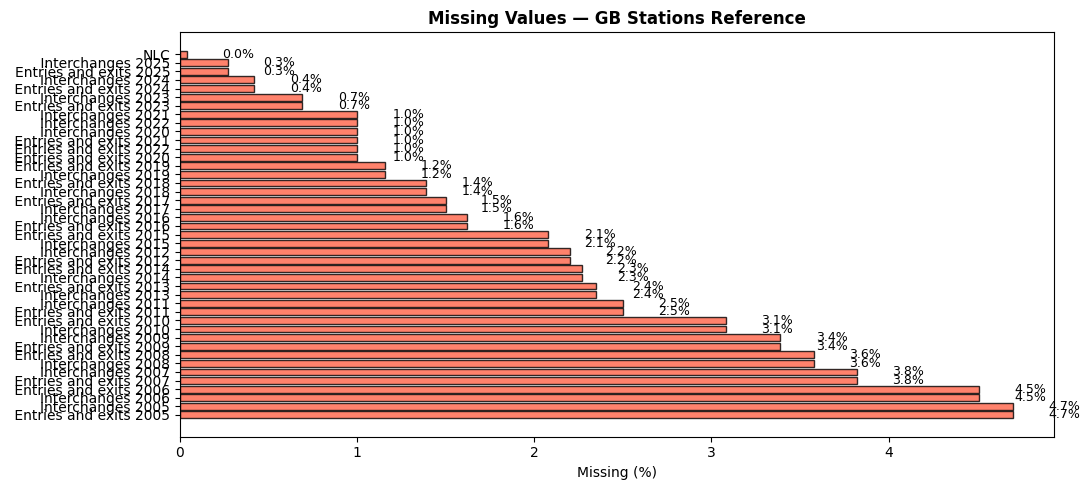

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
missing_nz = missing[missing["missing_pct"] > 0]
if len(missing_nz):
    ax.barh(missing_nz.index, missing_nz["missing_pct"], color="tomato", edgecolor="black", alpha=0.8)
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Values — GB Stations Reference", fontweight="bold")
    for i, v in enumerate(missing_nz["missing_pct"]):
        ax.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)
else:
    ax.text(0.5, 0.5, "No missing values", ha="center", va="center",
            transform=ax.transAxes, fontsize=14)
plt.tight_layout()
plt.savefig("figures/eda_03/missing_values.png", dpi=200, bbox_inches="tight")
plt.show()

In [10]:
# TLC (3-letter code) completeness — critical for station matching
if "TLC" in stations_df.columns:
    print(f"Unique TLC codes: {stations_df['TLC'].nunique()}")
    print(f"Missing TLC:      {stations_df['TLC'].isna().sum()}")
    print(f"Duplicate TLC:    {stations_df['TLC'].duplicated().sum()}")

Unique TLC codes: 2595
Missing TLC:      0
Duplicate TLC:    0


## 3. Owner/Operator Distribution

In [11]:
if "Owner" in stations_df.columns:
    owner_counts = stations_df["Owner"].value_counts()
    print(f"Unique owners/operators: {len(owner_counts)}")
    print()
    print(owner_counts.to_string())

Unique owners/operators: 34

Owner
Northern Trains                                       482
ScotRail                                              360
TfW Rail                                              248
Great Western Railway                                 201
South Western Railway                                 176
Southeastern                                          165
Govia Thameslink Railway (Southern)                   154
Greater Anglia                                        136
West Midlands Trains (West Midlands Railway)          113
East Midlands Railway                                  90
London Overground                                      82
Merseyrail                                             67
Govia Thameslink Railway (Great Northern)              47
West Midlands Trains (London Northwestern Railway)     36
Chiltern Railways                                      35
Govia Thameslink Railway (Thameslink)                  34
London Underground                   

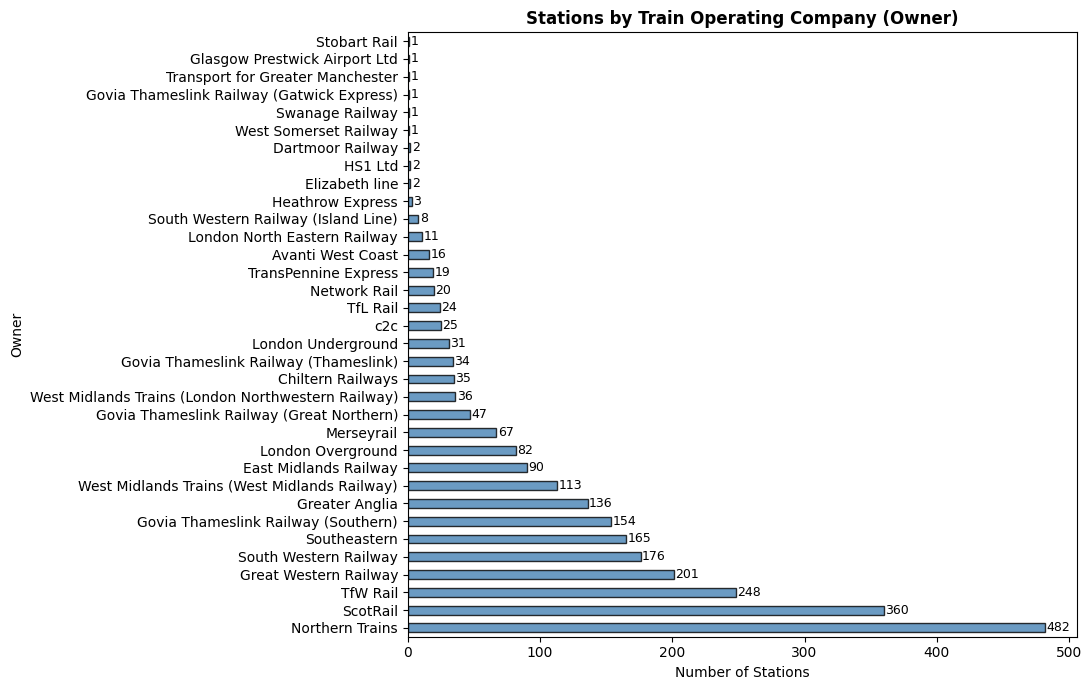

In [12]:
if "Owner" in stations_df.columns:
    owner_counts = stations_df["Owner"].value_counts()
    plt.figure(figsize=(11, 7))
    owner_counts.plot(kind="barh", color="steelblue", edgecolor="black", alpha=0.8)
    plt.xlabel("Number of Stations")
    plt.title("Stations by Train Operating Company (Owner)", fontweight="bold")
    for i, v in enumerate(owner_counts.values):
        plt.text(v + 1, i, str(v), va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_03/owner_distribution.png", dpi=200, bbox_inches="tight")
    plt.show()

## 4. Geographic Distribution

In [13]:
print("Geographic extent:")
print(f"  Latitude  range: {stations_df['Latitude'].min():.4f} — {stations_df['Latitude'].max():.4f}")
print(f"  Longitude range: {stations_df['Longitude'].min():.4f} — {stations_df['Longitude'].max():.4f}")
print(f"  Missing coordinates: {stations_df[['Latitude','Longitude']].isna().any(axis=1).sum()}")

Geographic extent:
  Latitude  range: 50.1217 — 58.5902
  Longitude range: -5.8391 — 1.7497
  Missing coordinates: 0


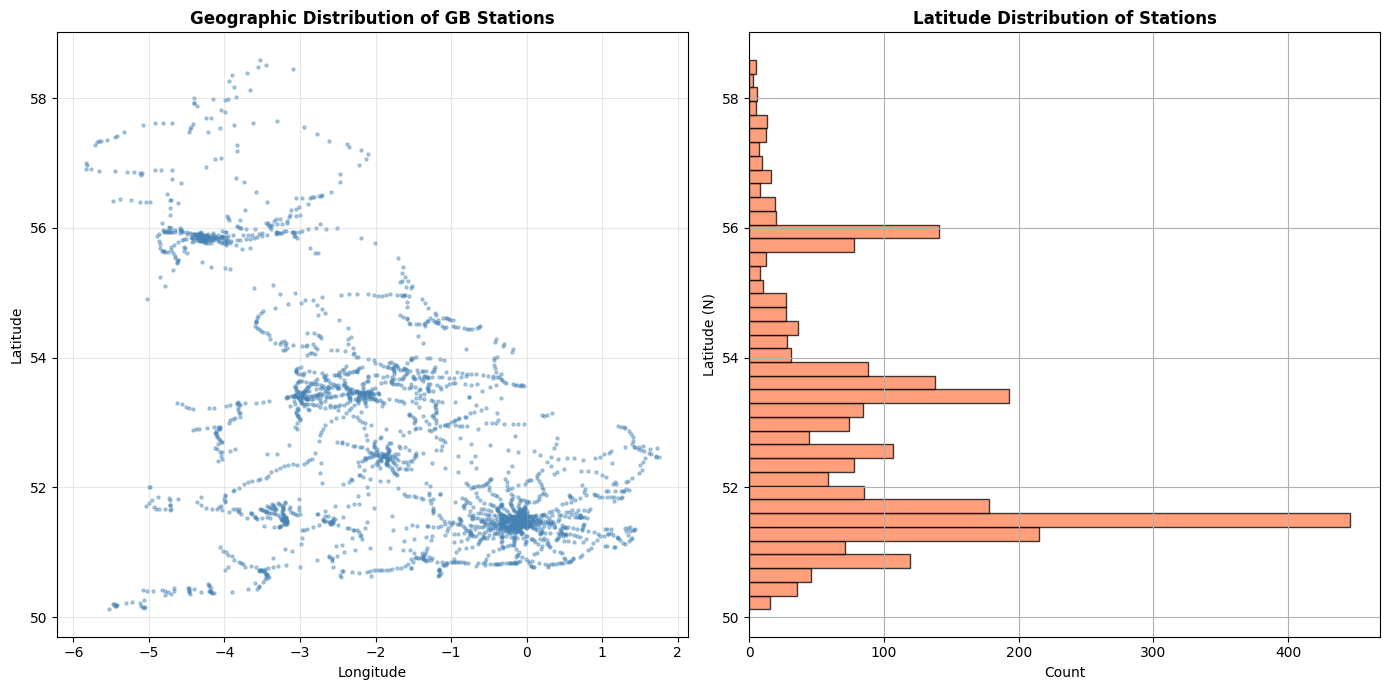

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Scatter: all stations
axes[0].scatter(stations_df["Longitude"], stations_df["Latitude"],
                s=5, alpha=0.4, color="steelblue")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Geographic Distribution of GB Stations", fontweight="bold")
axes[0].grid(alpha=0.3)

# Latitude histogram
stations_df["Latitude"].hist(bins=40, ax=axes[1], color="coral",
                              edgecolor="black", alpha=0.75, orientation="horizontal")
axes[1].set_ylabel("Latitude (N)")
axes[1].set_xlabel("Count")
axes[1].set_title("Latitude Distribution of Stations", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_03/geographic_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Footfall Analysis (2017–2025)

In [15]:
footfall_cols = [c for c in stations_df.columns if "Entries" in c]
print(f"Footfall columns found: {footfall_cols}")

Footfall columns found: ['Entries and exits 2025', ' Entries and exits 2024', ' Entries and exits 2023', ' Entries and exits 2022', ' Entries and exits 2021', ' Entries and exits 2020', ' Entries and exits 2019', ' Entries and exits 2018', ' Entries and exits 2017', ' Entries and exits 2016', ' Entries and exits 2015', ' Entries and exits 2014', ' Entries and exits 2013', ' Entries and exits 2012', ' Entries and exits 2011', ' Entries and exits 2010', ' Entries and exits 2009', ' Entries and exits 2008', ' Entries and exits 2007', ' Entries and exits 2006', ' Entries and exits 2005']


National footfall totals (millions of entries+exits):
2025    3054.8
2024    2844.5
2023    2451.6
2022    1788.5
2021     687.7
2020    3007.1
2019    3039.4
2018    2949.8
2017    2939.3
2016    2927.5
2015    2785.0
2014    2665.1
2013    2537.8
2012    2468.7
2011    2313.7
2010    2129.9
2009    2128.7
2008    2037.6
2007    1903.5
2006    1590.6
2005    1552.4


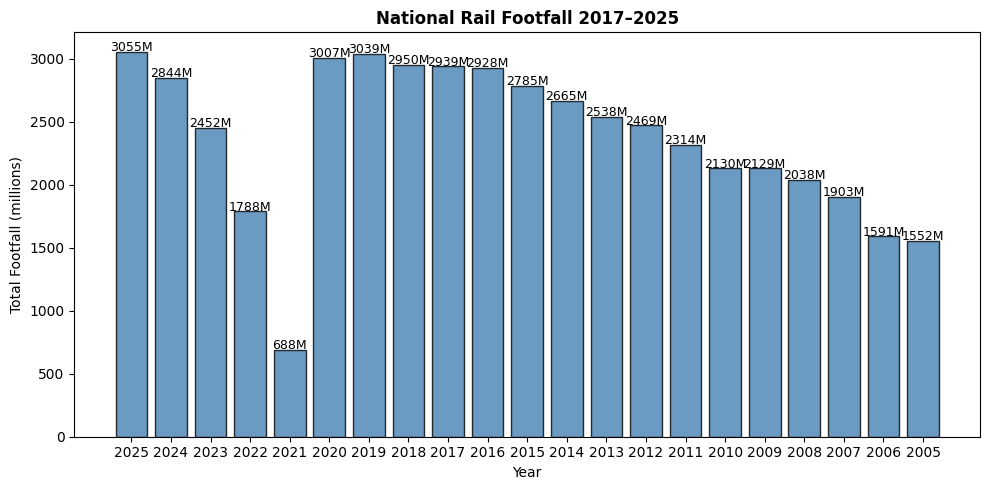

In [16]:
if footfall_cols:
    footfall_df = stations_df[["Station", "TLC"] + footfall_cols].copy()
    footfall_df.columns = ["Station", "TLC"] + [c.split()[-1] for c in footfall_cols]
    years = [c.split()[-1] for c in footfall_cols]

    # National totals by year
    totals = footfall_df[years].sum() / 1e6
    print("National footfall totals (millions of entries+exits):")
    print(totals.round(1).to_string())

    plt.figure(figsize=(10, 5))
    plt.bar(years, totals.values, color="steelblue", edgecolor="black", alpha=0.8)
    plt.xlabel("Year")
    plt.ylabel("Total Footfall (millions)")
    plt.title("National Rail Footfall 2017–2025", fontweight="bold")
    for i, v in enumerate(totals.values):
        plt.text(i, v + 5, f"{v:.0f}M", ha="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_03/national_footfall.png", dpi=200, bbox_inches="tight")
    plt.show()

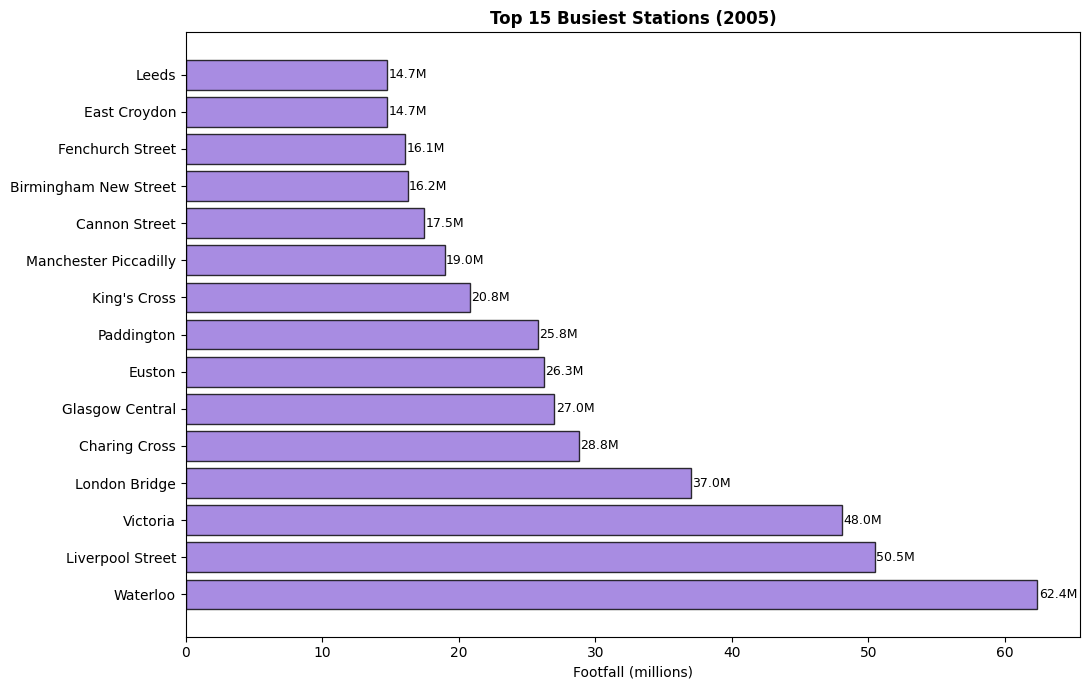

In [17]:
if footfall_cols and years:
    latest_year = years[-1]
    top_stations = footfall_df.nlargest(15, latest_year)[["Station", latest_year]]

    plt.figure(figsize=(11, 7))
    plt.barh(top_stations["Station"], top_stations[latest_year] / 1e6,
             color="mediumpurple", edgecolor="black", alpha=0.8)
    plt.xlabel("Footfall (millions)")
    plt.title(f"Top 15 Busiest Stations ({latest_year})", fontweight="bold")
    for i, v in enumerate(top_stations[latest_year] / 1e6):
        plt.text(v + 0.1, i, f"{v:.1f}M", va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_03/top_stations_footfall.png", dpi=200, bbox_inches="tight")
    plt.show()

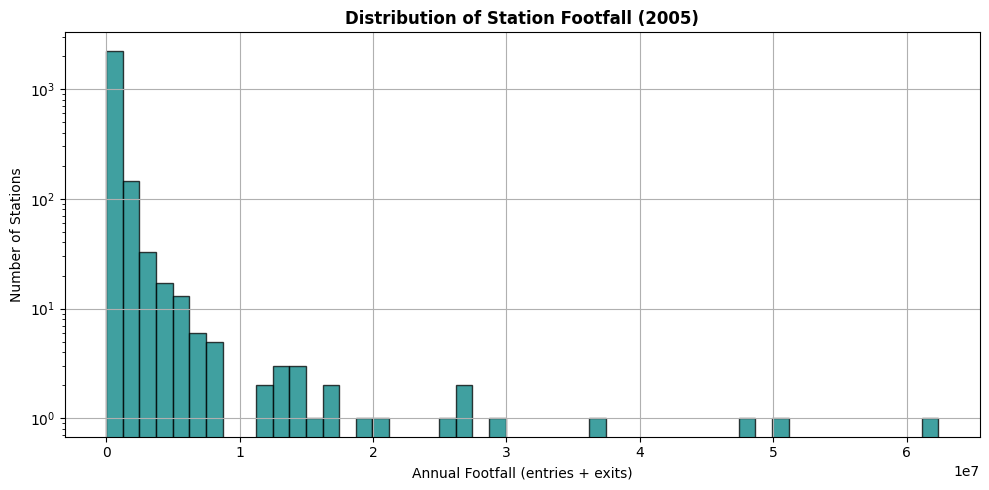

Note: log scale used because footfall is highly right-skewed.


In [18]:
if footfall_cols and years:
    # Footfall distribution: how skewed is usage across stations?
    plt.figure(figsize=(10, 5))
    stations_df[footfall_cols[-1]].dropna().hist(bins=50, color="teal",
                                                   edgecolor="black", alpha=0.75)
    plt.xlabel("Annual Footfall (entries + exits)")
    plt.ylabel("Number of Stations")
    plt.title(f"Distribution of Station Footfall ({years[-1]})", fontweight="bold")
    plt.yscale("log")
    plt.tight_layout()
    plt.savefig("figures/eda_03/footfall_distribution.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("Note: log scale used because footfall is highly right-skewed.")

## 6. TIPLOC Lookup Coverage Check

In [25]:
lookup_df = load_stations_lookup()
print(f"TIPLOC lookup shape: {lookup_df.shape}")
print(f"Columns: {list(lookup_df.columns)}")
lookup_df.head()

data\rail\corpusextract.json
TIPLOC lookup shape: (55920, 7)
Columns: ['NLC', 'STANOX', 'TIPLOC', '3ALPHA', 'UIC', 'NLCDESC', 'NLCDESC16']


,NLC,STANOX,TIPLOC,3ALPHA,UIC,NLCDESC,NLCDESC16
0,700,43423,FENTON,FMA,00070,FENTON MANOR,
1,800,,,,,MERSEYRAIL ELECTRICS-HQ INPUT,MPTE HQ INPUT
2,900,,,,,AUTHORISED INPUT LOCATION 0009,CAPRI HQ INPUT
3,1000,,,,,SPARE 166,SPARE 166
4,1100,,,,,SPARE 167,SPARE 167


In [26]:
# How many stations in gb_stations.csv can be matched to TIPLOC lookup via TLC/3ALPHA?
if "TLC" in stations_df.columns and "3ALPHA" in lookup_df.columns:
    station_tlcs = set(stations_df["TLC"].dropna().str.strip().str.upper())
    lookup_tlcs  = set(lookup_df["3ALPHA"].dropna().str.strip().str.upper())

    matched   = station_tlcs & lookup_tlcs
    unmatched = station_tlcs - lookup_tlcs

    print(f"Station TLCs in gb_stations:   {len(station_tlcs):,}")
    print(f"3ALPHA codes in TIPLOC lookup: {len(lookup_tlcs):,}")
    print(f"Matched (in both):             {len(matched):,} ({len(matched)/len(station_tlcs)*100:.1f}%)")
    print(f"Unmatched (stations only):     {len(unmatched):,} ({len(unmatched)/len(station_tlcs)*100:.1f}%)")

Station TLCs in gb_stations:   2,595
3ALPHA codes in TIPLOC lookup: 4,113
Matched (in both):             2,594 (100.0%)
Unmatched (stations only):     1 (0.0%)


In [27]:
if "3ALPHA" in lookup_df.columns and "STANOX" in lookup_df.columns:
    # STANOX completeness in the lookup
    STANOX_missing = lookup_df["STANOX"].isna().sum()
    print(f"TIPLOC records with STANOX:    {lookup_df['STANOX'].notna().sum():,}")
    print(f"TIPLOC records missing STANOX: {STANOX_missing:,} ({STANOX_missing/len(lookup_df)*100:.1f}%)")

TIPLOC records with STANOX:    55,920
TIPLOC records missing STANOX: 0 (0.0%)


## 7. Merge and Save Output

In [28]:
# Merge stations_df and lookup_df based on TLC and 3ALPHA
merge_df = stations_df.merge(lookup_df, left_on='TLC', right_on='3ALPHA')
merge_df.head()

# Keep columns relevant to analysis
col_list = ['Station','Postcode','Latitude','Longitude','TLC',  'NLC_x','STANOX','TIPLOC']
final_df = merge_df[col_list]
final_df.rename(columns={'NLC_x': 'NLC'}, inplace=True)
final_df.columns = final_df.columns.str.lower()
final_df.head()

,station,postcode,latitude,longitude,tlc,nlc,stanox,tiploc
0,Abbey Wood,SE2 9RH,51.491061,0.121394,ABW,5131.0,88601,ABWD
1,Aber,CF83 1AQ,51.574969,-3.229829,ABE,3813.0,78371,ABER
2,Abercynon,CF45 4SE,51.644712,-3.326989,ACY,3801.0,78204,ABRCYNS
3,Aberdare,CF44 0PU,51.715062,-3.443084,ABA,3982.0,78100,ABDARE
4,Aberdeen,AB11 6LX,57.143706,-2.098685,ABD,8976.0,02071,ABRDEEN


In [29]:
# Save stations reference
final_df.to_parquet("./data/processed/stations_reference.parquet", index=False)
print(f"Saved stations reference: {len(final_df):,} rows")

Saved stations reference: 2,594 rows


In [30]:
print("\nColumn summary:")
final_df.info()


Column summary:
<class 'pandas.DataFrame'>
RangeIndex: 2594 entries, 0 to 2593
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   station    2594 non-null   str    
 1   postcode   2594 non-null   str    
 2   latitude   2594 non-null   float64
 3   longitude  2594 non-null   float64
 4   tlc        2594 non-null   str    
 5   nlc        2593 non-null   float64
 6   stanox     2594 non-null   str    
 7   tiploc     2594 non-null   str    
dtypes: float64(3), str(5)
memory usage: 247.1 KB
